In [4]:
#imports
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [5]:
input_file = "Raw_data/output_2025-04-19_17-46-57_CB_Test.txt"
output_file = "CSVs/cell_balance_test.csv"

with open(input_file, "r") as f:
    content = f.read()

# Split into individual blocks
blocks = content.split("Time: ")
parsed_data = []

for block in blocks[1:]:  # skip the first split part (before first "Time:")
    time_match = re.match(r"(\d+)", block)
    time = time_match.group(1) if time_match else ""

    data = {
        "Time": time,
    }

    # Voltage summary
    summary_keys = ["total_v", "max_v", "min_v", "avg_v"]
    for key in summary_keys:
        match = re.search(rf"{key}:\s*([\d.]+)", block)
        data[key] = match.group(1) if match else ""

    # max-min
    match = re.search(r"max-min:\s*([\d.]+)", block)
    data["max-min"] = match.group(1) if match else ""

    # Cell voltages
    for i in range(1, 141):
        match = re.search(rf"C{i}=([\d.]+)V", block)
        data[f"C{i}"] = match.group(1) if match else ""

    # Temperature summary
    for key in ["max_temp", "min_temp", "avg_temp"]:
        match = re.search(rf"{key}:\s*([\d.]+)", block)
        data[key] = match.group(1) if match else ""

    # Error flags
    for key in ["undervoltage", "overvoltage", "pec", "overtemperature", "openwire", "openwire_temp"]:
        match = re.search(rf"{key}:\s*(\d+)", block)
        data[key] = match.group(1) if match else ""

    for i in range(1, 11):
        match = re.search(rf"dcc{i}: ([0-9a-fA-F]+)", block)
        data[f"dcc{i}"] = int(match.group(1),16).bit_count() if match else ""

    parsed_data.append(data)

# Write to CSV
with open(output_file, "w", newline="") as csvfile:
    fieldnames = parsed_data[0].keys()
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(parsed_data)

print(f"CSV saved as: {output_file}")


CSV saved as: CSVs/cell_balance_test.csv


In [6]:
df = pd.read_csv("CSVs/cell_balance_test.csv")
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

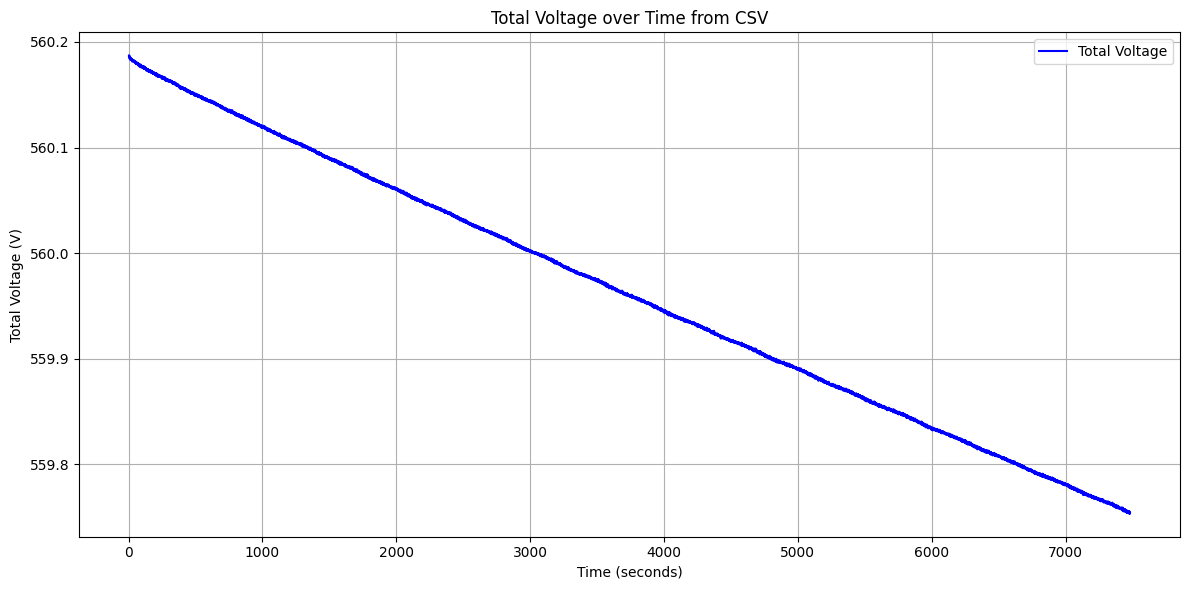

In [7]:
# Ensure numeric types for plotting
df["total_v"] = pd.to_numeric(df["total_v"], errors="coerce")

# Drop rows with missing values just in case
df = df.dropna(subset=["Time", "total_v"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Time"]/1000, df["total_v"], label="Total Voltage", color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Total Voltage (V)")
plt.title("Total Voltage over Time from CSV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

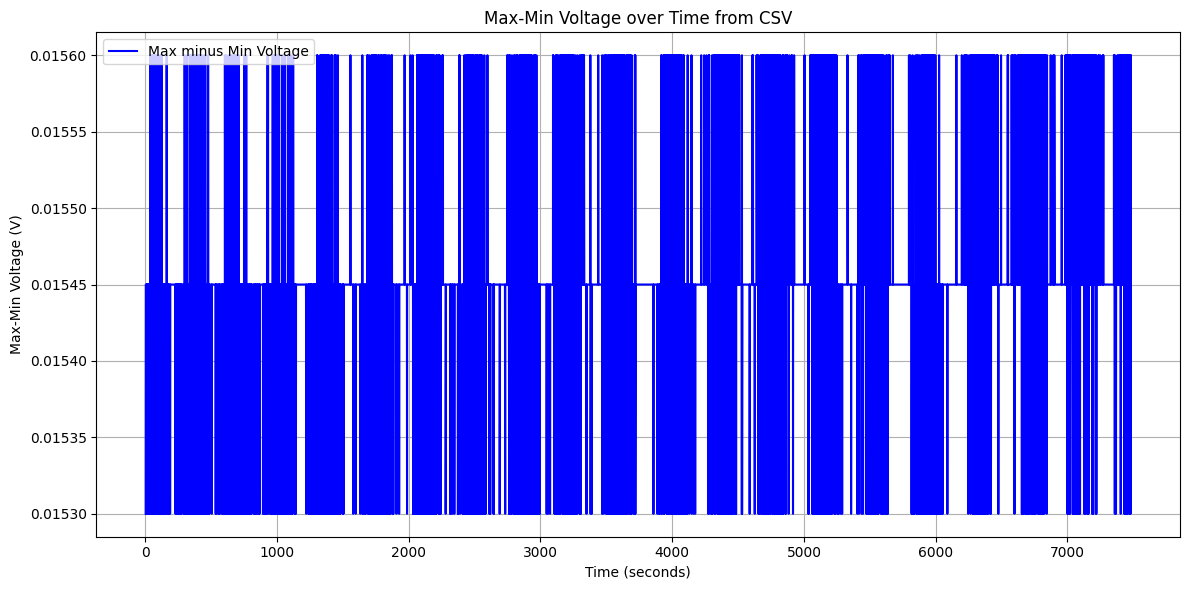

In [8]:
# Ensure numeric types for plotting
df["max-min"] = pd.to_numeric(df["max-min"], errors="coerce")

# Drop rows with missing values just in case
df = df.dropna(subset=["Time", "max-min"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Time"]/1000, df["max-min"], label="Max minus Min Voltage", color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Max-Min Voltage (V)")
plt.title("Max-Min Voltage over Time from CSV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

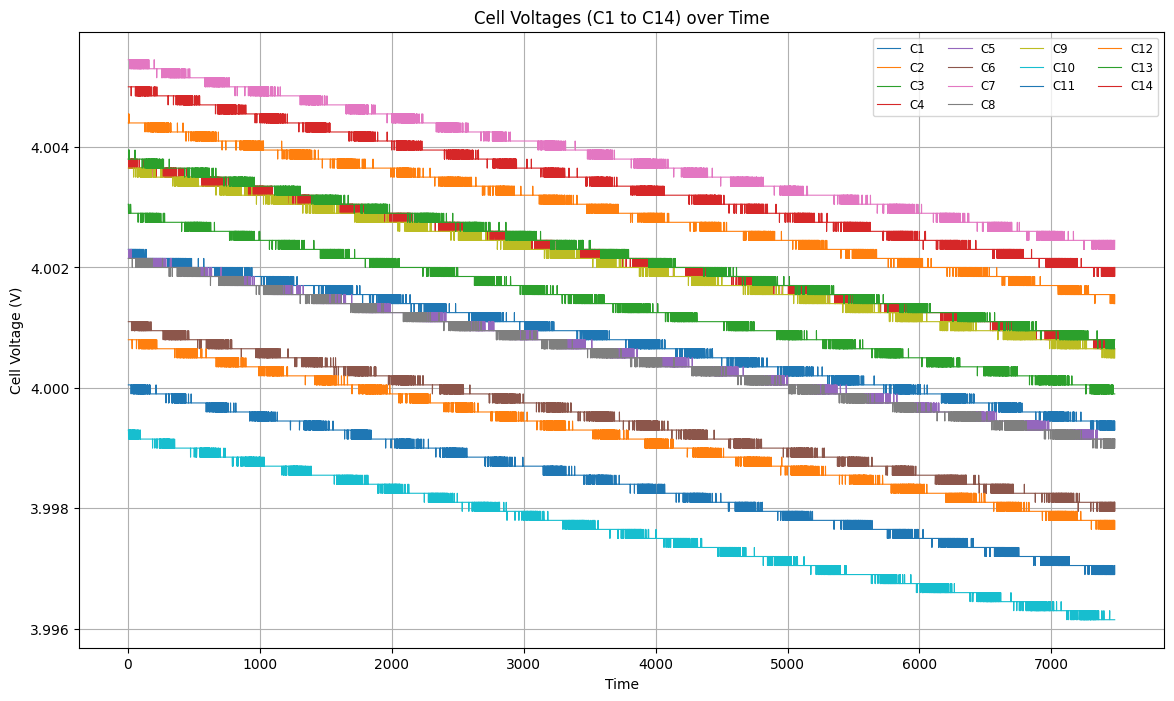

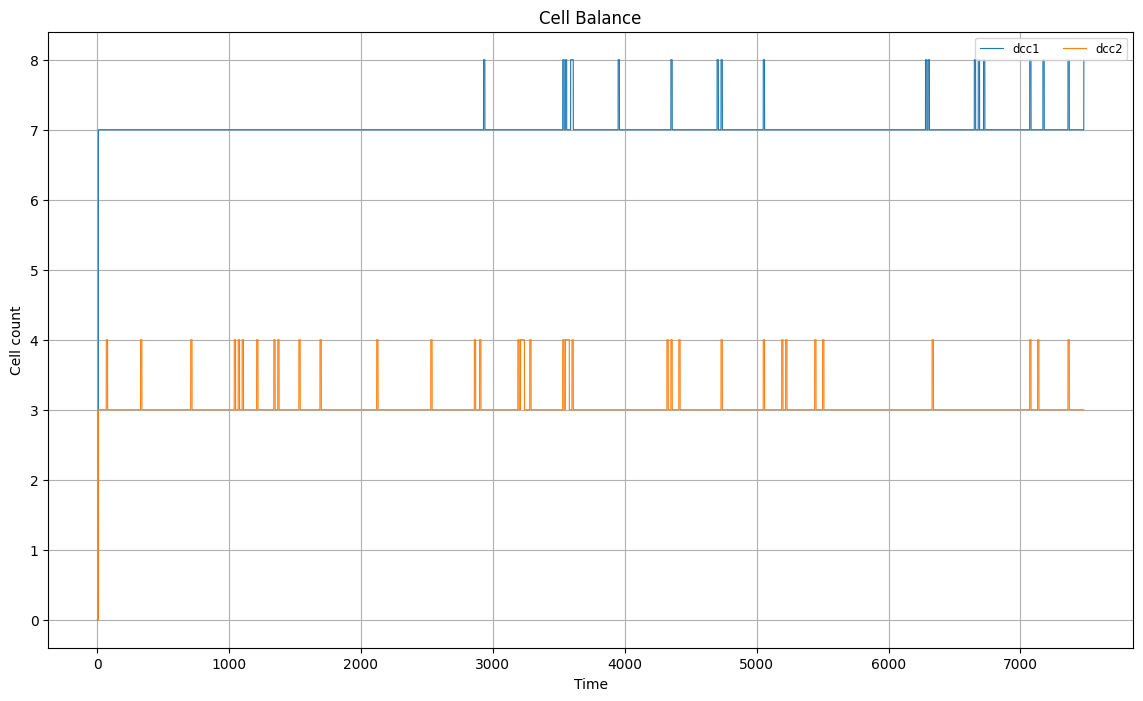

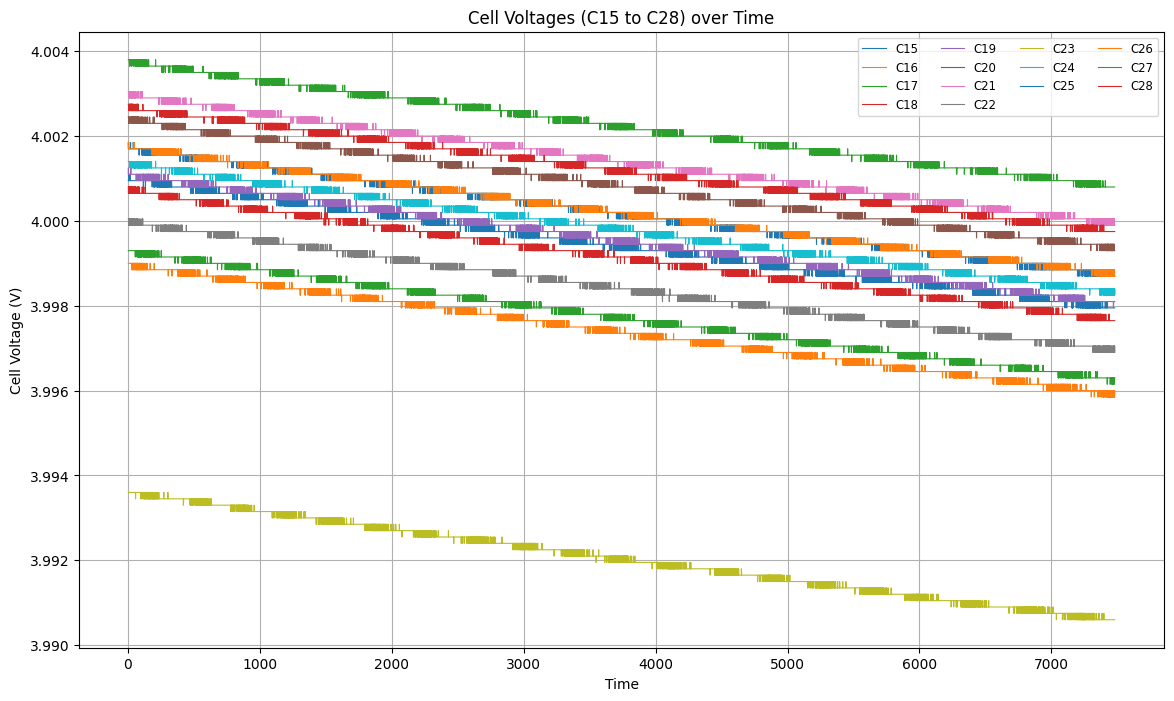

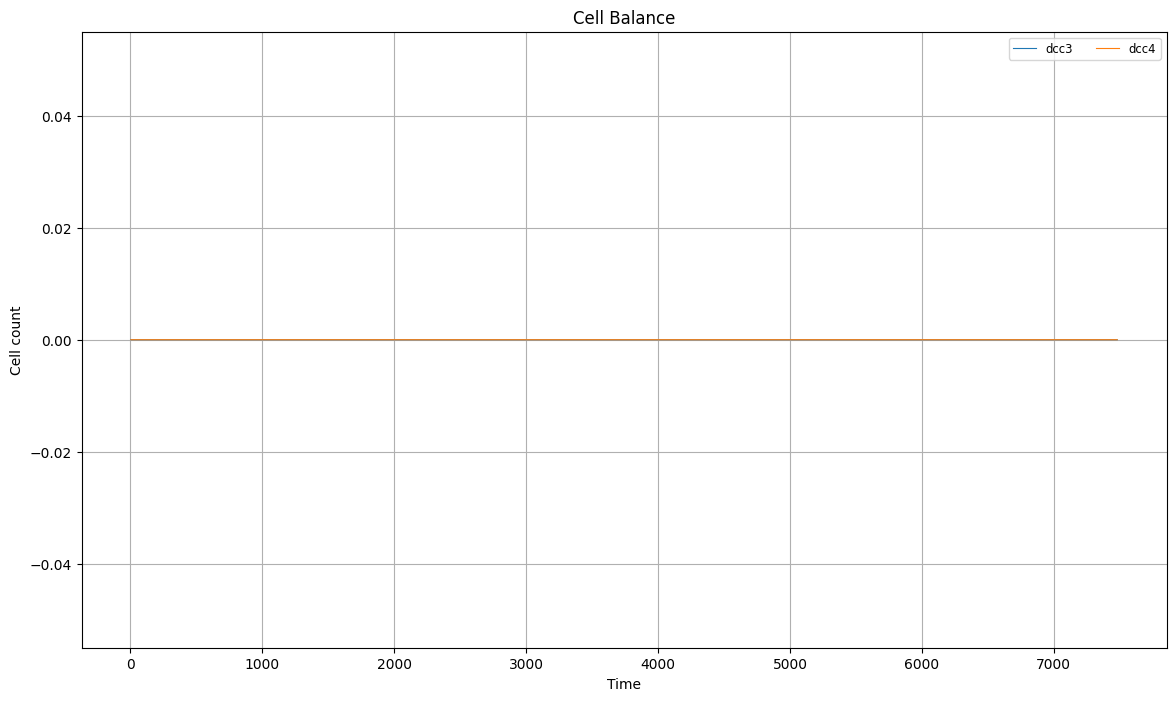

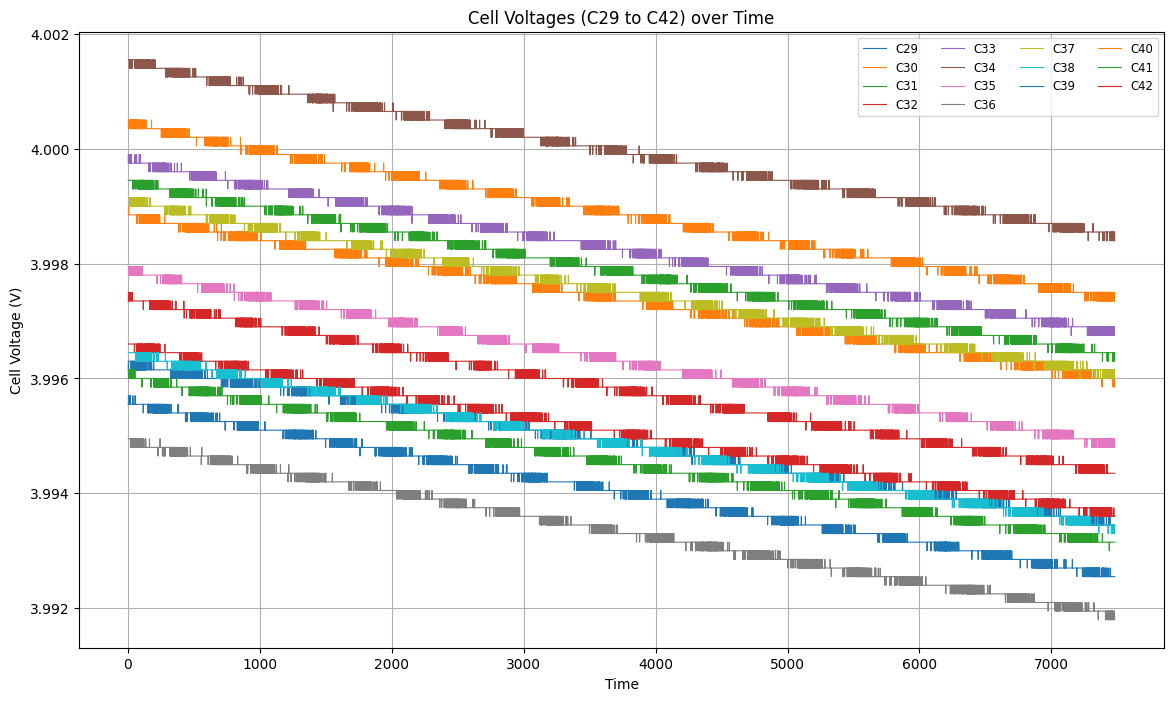

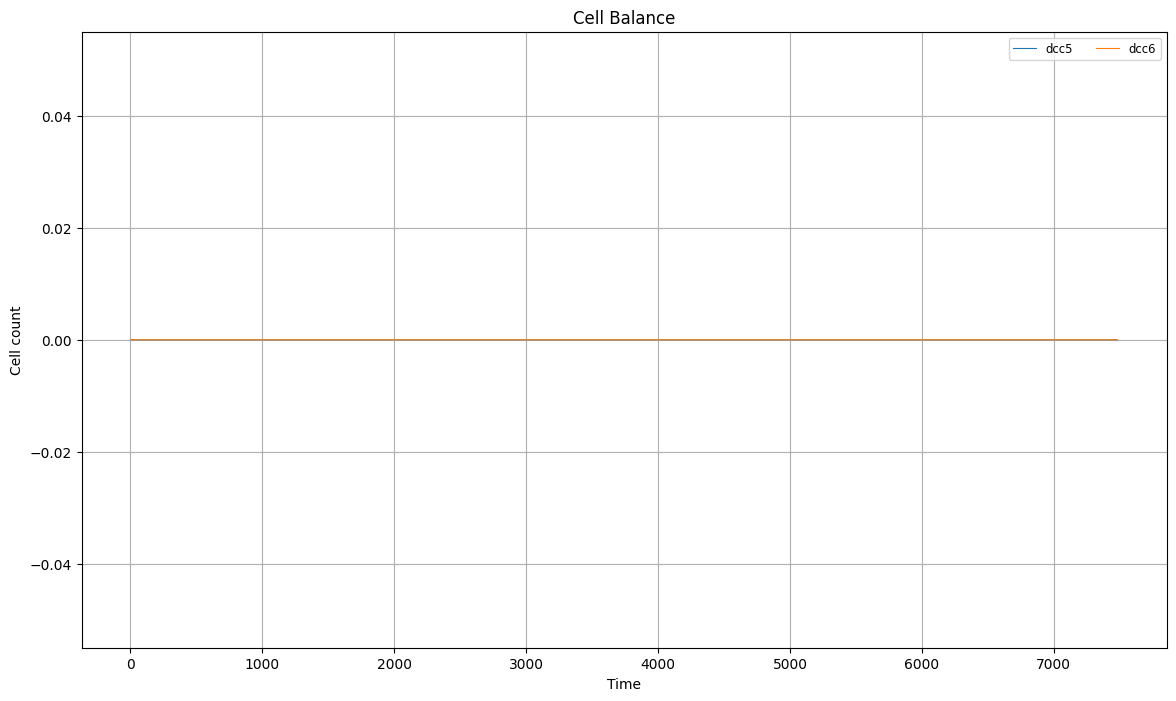

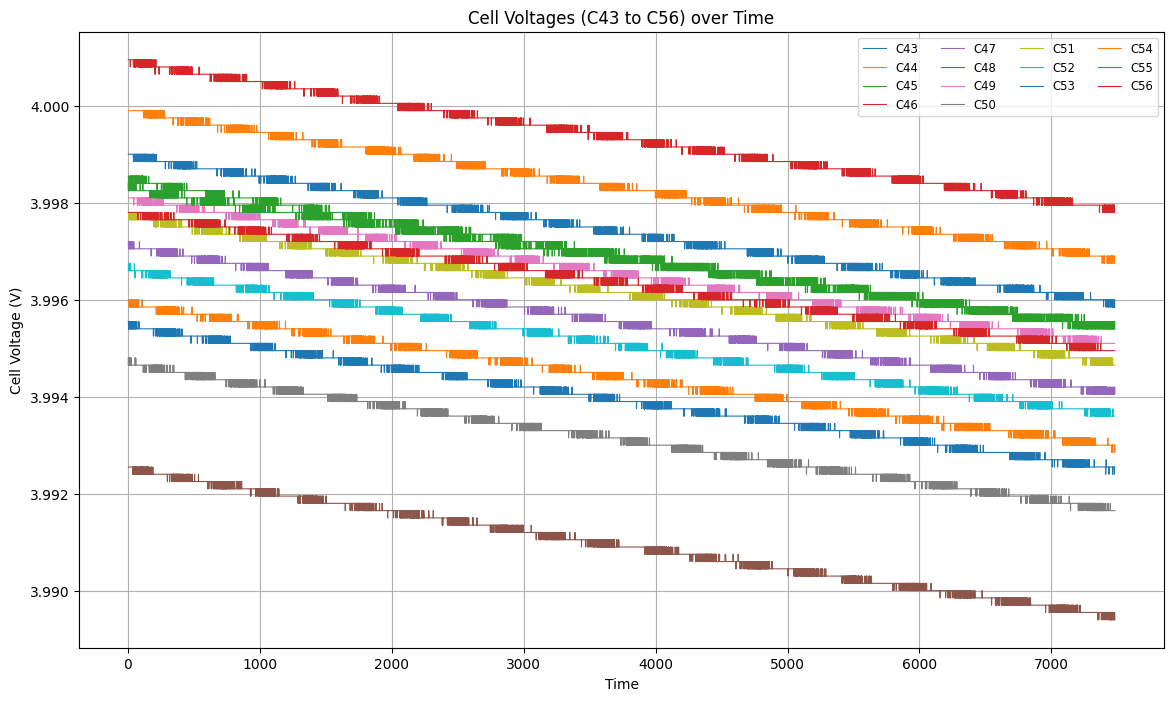

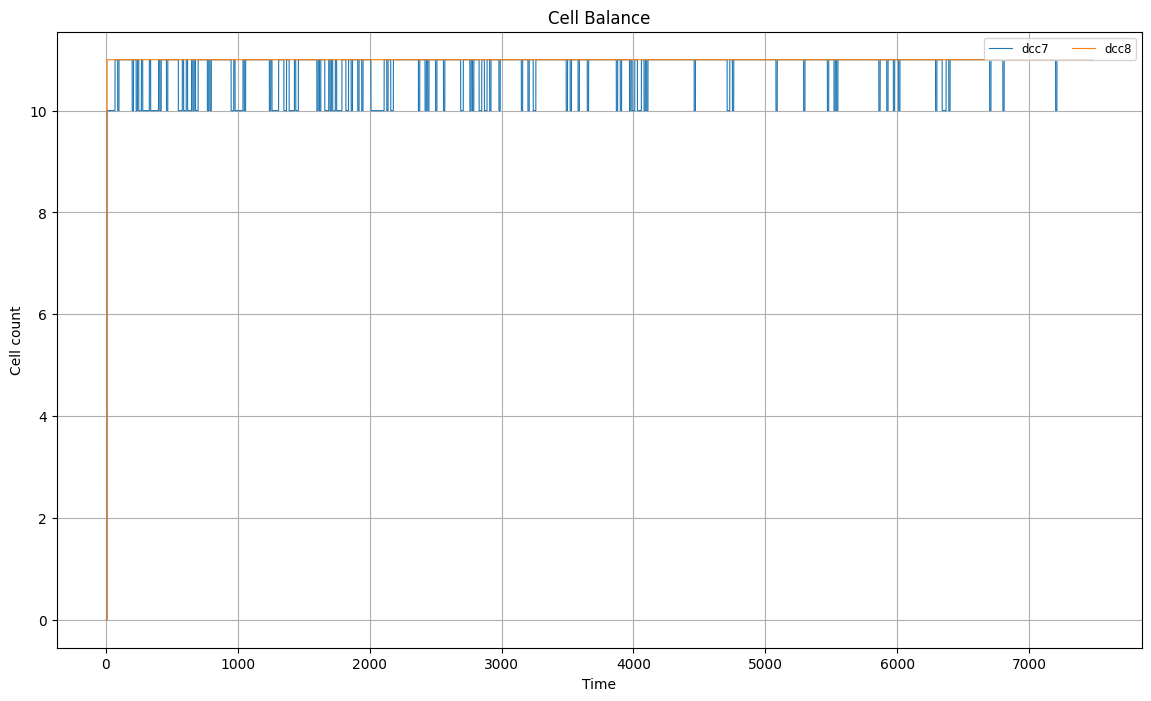

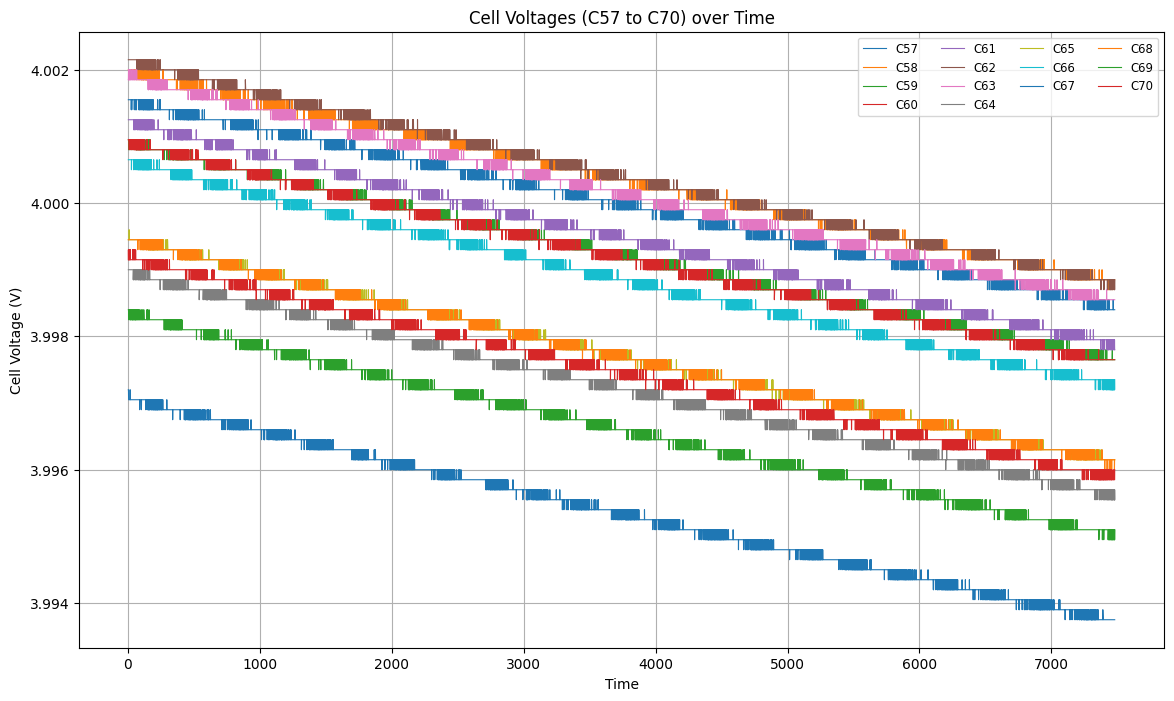

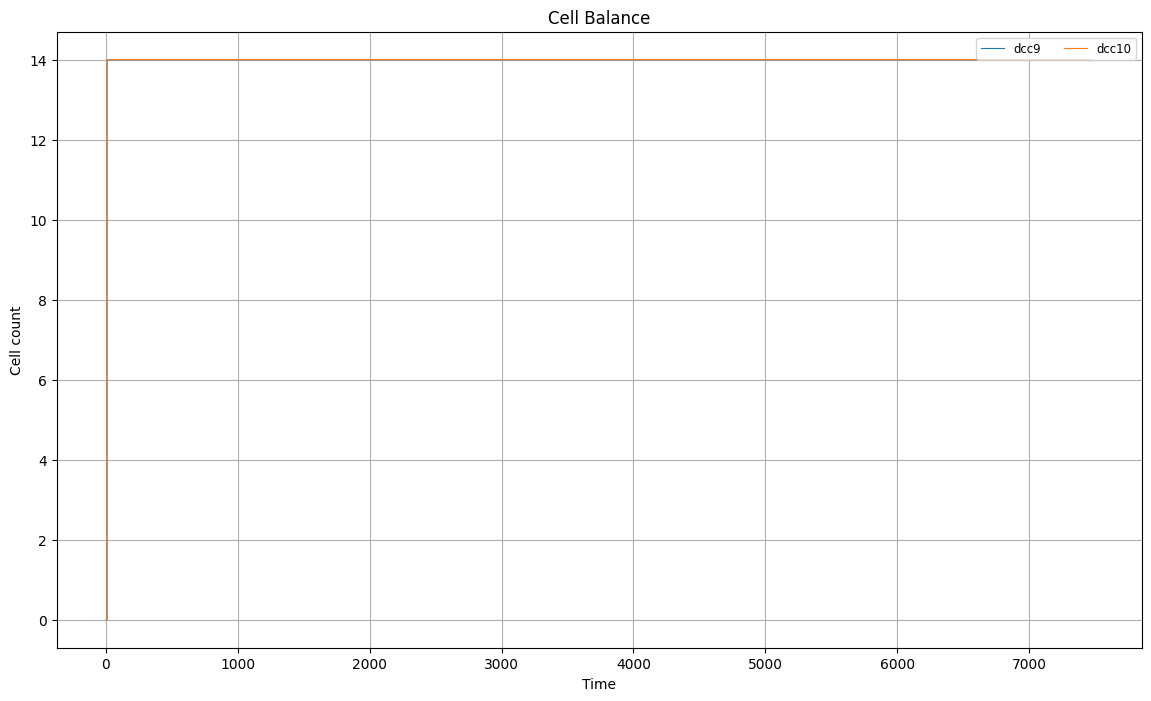

In [9]:
for i in range(1, 11):
    df[f"dcc{i}"] = pd.to_numeric(df[f"dcc{i}"], errors="coerce")

df = df.dropna(subset=["Time"])

for i in range(1, 141):
    df[f"C{i}"] = pd.to_numeric(df[f"C{i}"], errors="coerce")

df = df.dropna(subset=["Time"])

for i in range(5):
    plt.figure(figsize=(14, 8))
    for j in range(14 * i + 1, 14 * i + 1 + 14):
        plt.plot(df["Time"]/1000, df[f"C{j}"], label=f"C{j}", linewidth=0.8)
    plt.xlabel("Time")
    plt.ylabel("Cell Voltage (V)")
    plt.title(f"Cell Voltages (C{14 * i + 1} to C{14 * i + 14}) over Time")
    plt.legend(ncol=4, fontsize="small", loc="upper right")
    plt.grid(True)
    plt.axes
    plt.figure(figsize=(14, 8))
    for j in range(2 * i + 1, 2 * i + 3):
        plt.plot(df["Time"]/1000, df[f"dcc{j}"], label=f"dcc{j}", linewidth=0.8)
    plt.xlabel("Time")
    plt.ylabel("Cell count")
    plt.title("Cell Balance")
    plt.legend(ncol=4, fontsize="small", loc="upper right")
    plt.grid(True)
    plt.axes
# plt.ylim((2.5,4.2))
# plt.tight_layout()
plt.show()

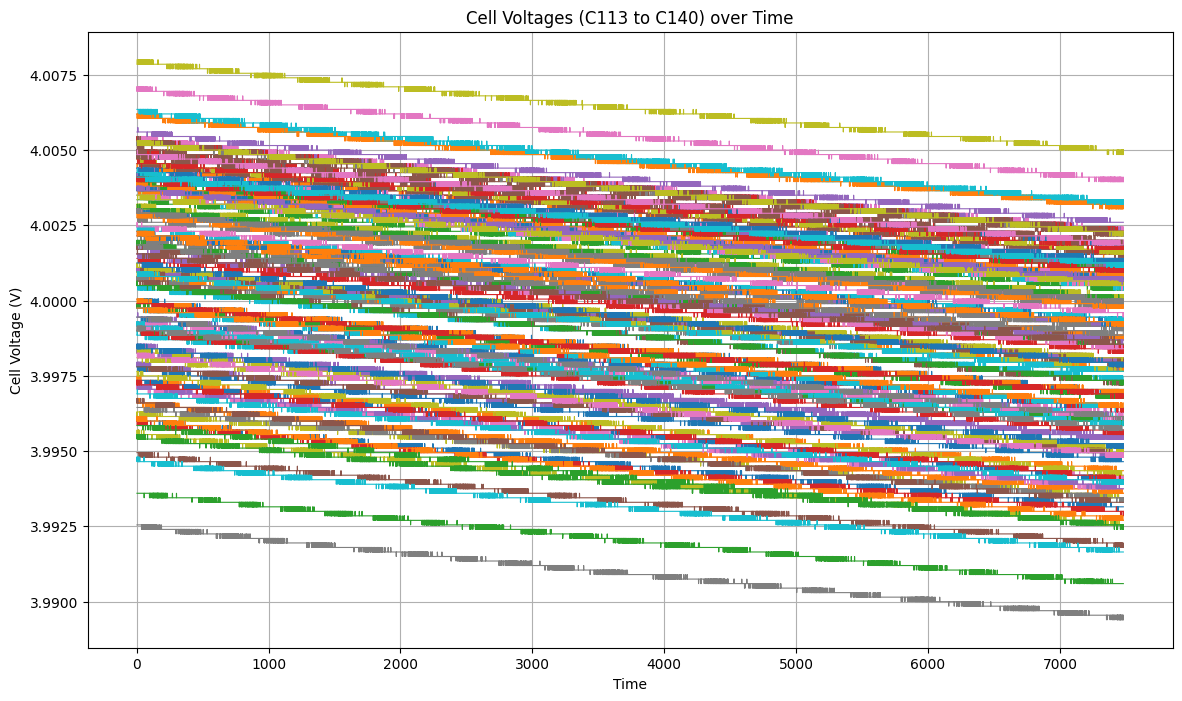

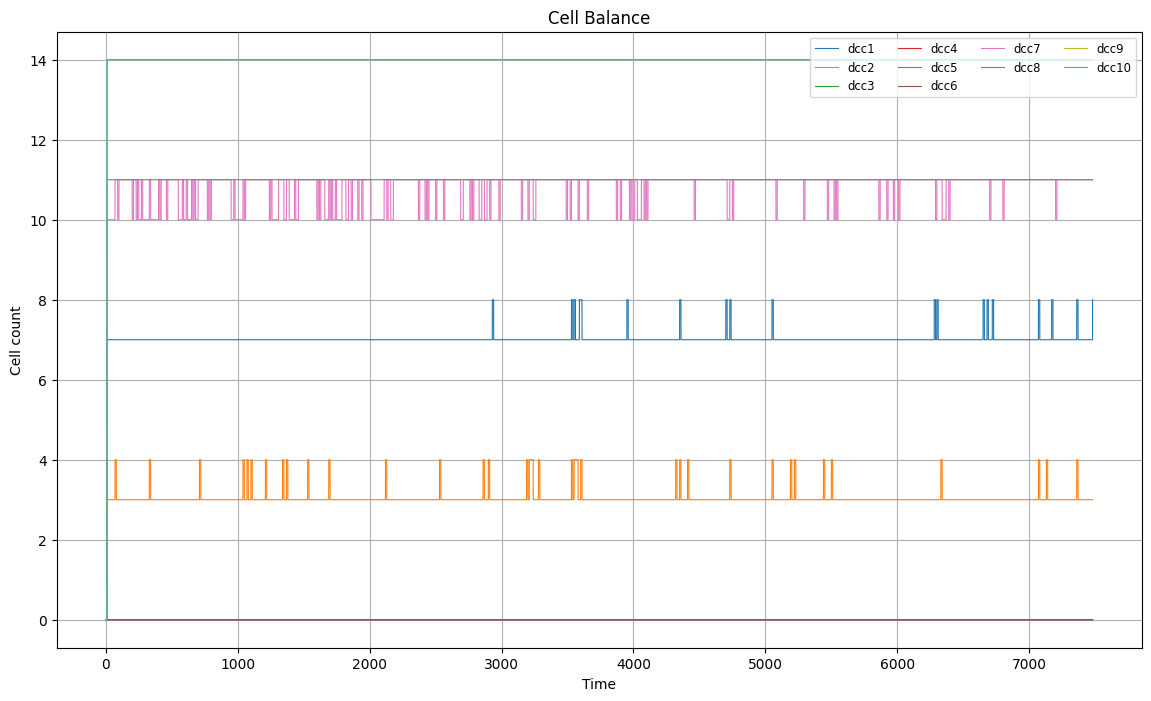

In [7]:
plt.figure(figsize=(14, 8))
for j in range(1,141):
    plt.plot(df["Time"]/1000, df[f"C{j}"], label=f"C{j}", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Cell Voltage (V)")
plt.title(f"Cell Voltages (C{28 * i + 1} to C{28 * i + 28}) over Time")
# plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes
plt.figure(figsize=(14, 8))
for j in range(1,11):
    plt.plot(df["Time"]/1000, df[f"dcc{j}"], label=f"dcc{j}", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Cell count")
plt.title("Cell Balance")
plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes

plt.show()

0.002850000000000019


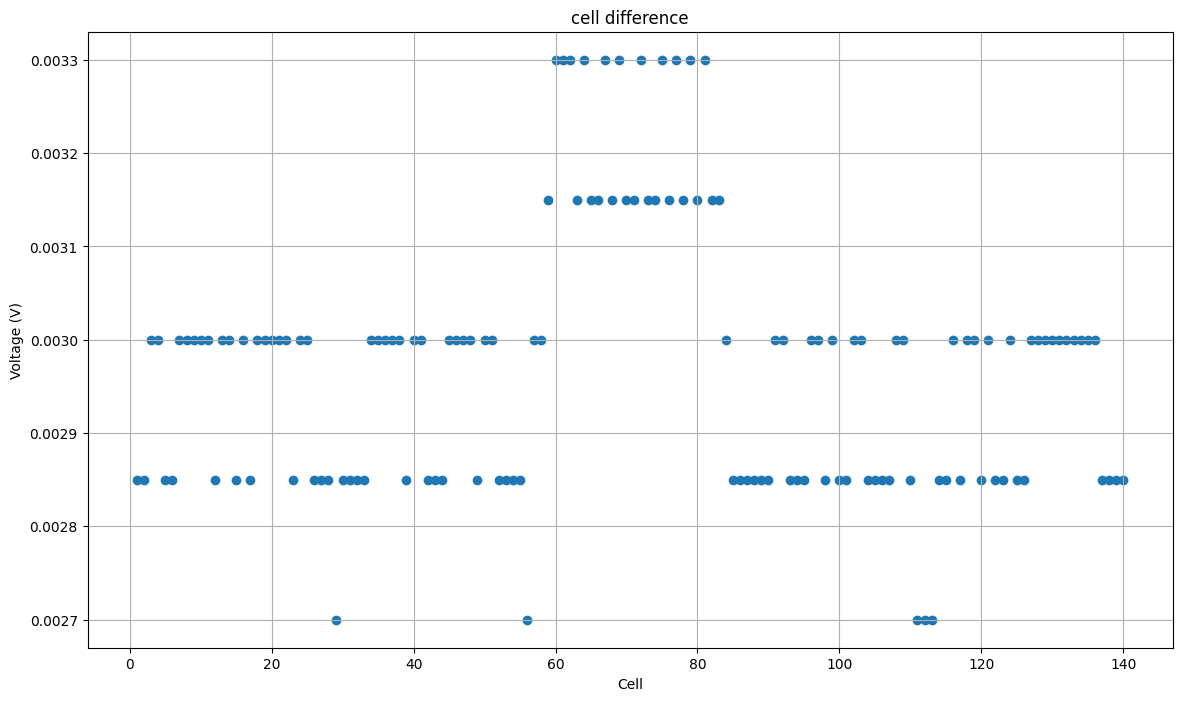

In [8]:
plt.figure(figsize=(14, 8))
print(df[f"C{1}"][0] - df[f"C{1}"][12175])

line = [df[f"C{j}"][0] - df[f"C{j}"][12175] for j in range(1, 141)]
x = np.arange(1, 141)
plt.scatter(x, line)

plt.xlabel("Cell")
plt.ylabel("Voltage (V)")
plt.title("cell difference")
# plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes
plt.show()